# Pregunta 7: Mapas de métricas de duración de dry spells (CR2MET vs ALADIN histórico) y delta

## Objetivo
Construir mapas para el periodo histórico común **1980–2014** de métricas de duración de **dry spells** en:

- **CR2MET** (interpolado a la grilla ALADIN)
- **ALADIN histórico** (grilla nativa)
- **Delta**: \(\Delta = \text{ALADIN} - \text{CR2MET}\)

## Opción B (seleccionada)
Definición de **día seco** consistente con la calibración de wet-days (Pregunta 6):

- **CR2MET**: día seco si `pr < 1.0 mm/día`
- **ALADIN**: día seco si `pr < 5.285 mm/día` (\(\tau^*\) que iguala la fracción integrada de wet days cuando CR2MET usa 1 mm)

## Dominio
- Máscara: **Chile continental** (Natural Earth `admin_0_countries`, 10m)
- Grilla de referencia: **ALADIN CHP12** (`y`×`x`, `lat/lon` 2D)
- **CR2MET** se interpola linealmente a esa grilla (`xarray.interp`)

## Métricas (por píxel)
- **mean**: duración promedio de dry spells (días)
- **t99**: percentil 99 de duración (días)
- **tL**: cutoff de cola (opcional; suele ser más inestable espacialmente)


In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from IPython.display import display
from shapely.geometry import Point
from shapely.ops import unary_union
from shapely.prepared import prep

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = False

# =====================================================================
# CONFIGURACION
# =====================================================================
START_DATE = '1980-01-01'
END_DATE = '2014-12-31'

# Opcion B (de Pregunta 6)
DRY_THRESHOLD_CR2MET = 1.0
DRY_THRESHOLD_ALADIN = 5.285  # tau* equivalente (mm/dia)

# Control de estabilidad / performance
MIN_SPELLS_FOR_STATS = 30
COMPUTE_TL = False  # cambia a True si necesitas tL
CHILE_EXTENT = [-76, -65, -55, -17]

DOMAIN_MASK_RESOLUTION = '10m'


# =====================================================================
# DOMINIO COMUN (igual que pruea.ipynb)
# =====================================================================
def load_chile_geometry():
    shp_path = shpreader.natural_earth(
        resolution=DOMAIN_MASK_RESOLUTION,
        category='cultural',
        name='admin_0_countries',
    )
    reader = shpreader.Reader(shp_path)
    geoms = [
        record.geometry
        for record in reader.records()
        if record.attributes.get('NAME') == 'Chile' or record.attributes.get('ADMIN') == 'Chile'
    ]
    if not geoms:
        raise RuntimeError('No se encontro Chile en Natural Earth admin_0_countries')
    return unary_union(geoms)


def build_chile_mask_on_aladin_grid(lat2d, lon2d, geometry):
    prepared = prep(geometry)
    flat_mask = np.fromiter(
        (
            prepared.contains(Point(float(x), float(y))) or geometry.touches(Point(float(x), float(y)))
            for y, x in zip(lat2d.ravel(), lon2d.ravel())
        ),
        dtype=bool,
        count=lat2d.size,
    )
    return flat_mask.reshape(lat2d.shape)


def open_aladin_historical():
    ds = xr.open_mfdataset('./pr1/pr_CHP12_*_historical_*.nc', use_cftime=True, chunks={'time': 365})
    # kg m-2 s-1 -> mm/dia
    return ds['pr'].sel(time=slice(START_DATE, END_DATE)) * 86400.0


def open_cr2met_historical():
    ds = xr.open_mfdataset('./pr/CR2MET_pr_v2.5_day_*.nc', chunks={'time': 365})
    return ds['pr'].sel(time=slice(START_DATE, END_DATE))


def regrid_cr2met_to_aladin(pr_cr2met, pr_aladin_template):
    # xarray.interp(method='linear') requiere scipy instalado
    return pr_cr2met.interp(
        lat=pr_aladin_template['lat'],
        lon=pr_aladin_template['lon'],
        method='linear',
    )


print('1/4: Cargando datos y construyendo dominio comun...')
pr_aladin = open_aladin_historical()
pr_cr2met_native = open_cr2met_historical()

chile_geom = load_chile_geometry()
chile_mask_bool = build_chile_mask_on_aladin_grid(pr_aladin['lat'].values, pr_aladin['lon'].values, chile_geom)
chile_mask = xr.DataArray(
    chile_mask_bool,
    coords={'y': pr_aladin['y'], 'x': pr_aladin['x'], 'lat': pr_aladin['lat'], 'lon': pr_aladin['lon']},
    dims=['y', 'x'],
    name='chile_mask',
)

pr_cr2met = regrid_cr2met_to_aladin(pr_cr2met_native, pr_aladin)
pr_cr2met_chile = pr_cr2met.where(chile_mask)
pr_aladin_chile = pr_aladin.where(chile_mask)

print(f'Periodo: {START_DATE} a {END_DATE}')
print(f'Celdas validas Chile (grilla ALADIN): {int(chile_mask.sum().values)}')
print(f'Dry threshold CR2MET: {DRY_THRESHOLD_CR2MET} mm/dia | ALADIN (tau*): {DRY_THRESHOLD_ALADIN} mm/dia')


1/4: Cargando datos y construyendo dominio comun...
Periodo: 1980-01-01 a 2014-12-31
Celdas validas Chile (grilla ALADIN): 3587
Dry threshold CR2MET: 1.0 mm/dia | ALADIN (tau*): 5.285 mm/dia


In [5]:
# =====================================================================
# DRY SPELLS: EXTRACCION DE DURACIONES Y METRICAS POR PIXEL
# =====================================================================
def run_lengths_1d(bool_series):
    """Duraciones de tramos consecutivos True en una serie booleana 1D."""
    x = np.asarray(bool_series, dtype=np.bool_)
    if x.size == 0:
        return np.array([], dtype=np.int16)
    padded = np.r_[False, x, False]
    dx = np.diff(padded.astype(np.int8))
    starts = np.where(dx == 1)[0]
    ends = np.where(dx == -1)[0]
    return (ends - starts).astype(np.int16)


def metrics_from_durations(durations, min_spells=MIN_SPELLS_FOR_STATS, compute_tL=COMPUTE_TL):
    durations = np.asarray(durations, dtype=float)
    durations = durations[np.isfinite(durations) & (durations > 0)]
    n = int(durations.size)
    if n < min_spells:
        return {'mean': np.nan, 't99': np.nan, 'tL': np.nan, 'n_spells': n}

    mean_dur = float(np.mean(durations))
    t99 = float(np.percentile(durations, 99))

    tL = np.nan
    if compute_tL and np.max(durations) > np.min(durations):
        # Replica simplificada del enfoque en preg2(fecha17abril).ipynb
        try:
            bins = np.logspace(np.log10(np.min(durations)), np.log10(np.max(durations)), 15)
            hist, edges = np.histogram(durations, bins=bins, density=True)
            centers = np.sqrt(edges[:-1] * edges[1:])

            # Ajuste lineal en log-log de la cola (filtrando ceros)
            valid = (hist > 0) & np.isfinite(hist) & np.isfinite(centers)
            if valid.sum() >= 5:
                X = np.c_[np.ones(valid.sum()), np.log(centers[valid])]
                Y = np.log(hist[valid])
                coef, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
                # Heuristica: un cutoff proporcional al inverso de la pendiente
                slope = float(coef[1])
                tL = float(-1.0 / slope) if slope < 0 else np.nan
        except Exception:
            tL = np.nan

    return {'mean': mean_dur, 't99': t99, 'tL': tL, 'n_spells': n}


def pixelwise_spell_metrics(pr_masked, dry_threshold, mask_da, compute_tL=COMPUTE_TL):
    """Calcula mapas de métricas de duración de rachas secas para todo el periodo."""
    # Convertimos a bool por eficiencia y cargamos en memoria como (time, cell)
    is_dry = (pr_masked < dry_threshold).where(mask_da)
    dry_stacked = is_dry.stack(cell=('y', 'x')).transpose('time', 'cell').compute()
    dry_vals = dry_stacked.values  # bool (time, cell)

    # Prealocacion
    out = {
        'mean': np.full(dry_vals.shape[1], np.nan, dtype=np.float32),
        't99': np.full(dry_vals.shape[1], np.nan, dtype=np.float32),
        'tL': np.full(dry_vals.shape[1], np.nan, dtype=np.float32),
        'n_spells': np.full(dry_vals.shape[1], 0, dtype=np.int32),
    }

    for idx in range(dry_vals.shape[1]):
        col = dry_vals[:, idx]
        if not np.any(col):
            continue
        durs = run_lengths_1d(col)
        m = metrics_from_durations(durs, compute_tL=compute_tL)
        out['mean'][idx] = m['mean']
        out['t99'][idx] = m['t99']
        out['tL'][idx] = m['tL']
        out['n_spells'][idx] = m['n_spells']

    # Volver a grilla 2D
    maps = {}
    for key in ['mean', 't99', 'tL', 'n_spells']:
        da_1d = xr.DataArray(out[key], coords={'cell': dry_stacked['cell']}, dims=['cell'])
        da_2d = da_1d.unstack('cell')
        da_2d = da_2d.assign_coords(lat=mask_da['lat'], lon=mask_da['lon'])
        maps[key] = da_2d

    return maps


print('2/4: Calculando métricas de duración por píxel (esto puede tardar)...')

metrics_cr2 = pixelwise_spell_metrics(pr_cr2met_chile, DRY_THRESHOLD_CR2MET, chile_mask, compute_tL=COMPUTE_TL)
metrics_ala = pixelwise_spell_metrics(pr_aladin_chile, DRY_THRESHOLD_ALADIN, chile_mask, compute_tL=COMPUTE_TL)

metrics_delta = {k: (metrics_ala[k] - metrics_cr2[k]) for k in ['mean', 't99', 'tL']}

print('Listo. Métricas disponibles:', list(metrics_cr2.keys()))


2/4: Calculando métricas de duración por píxel (esto puede tardar)...
Listo. Métricas disponibles: ['mean', 't99', 'tL', 'n_spells']


3/4: Generando mapas...


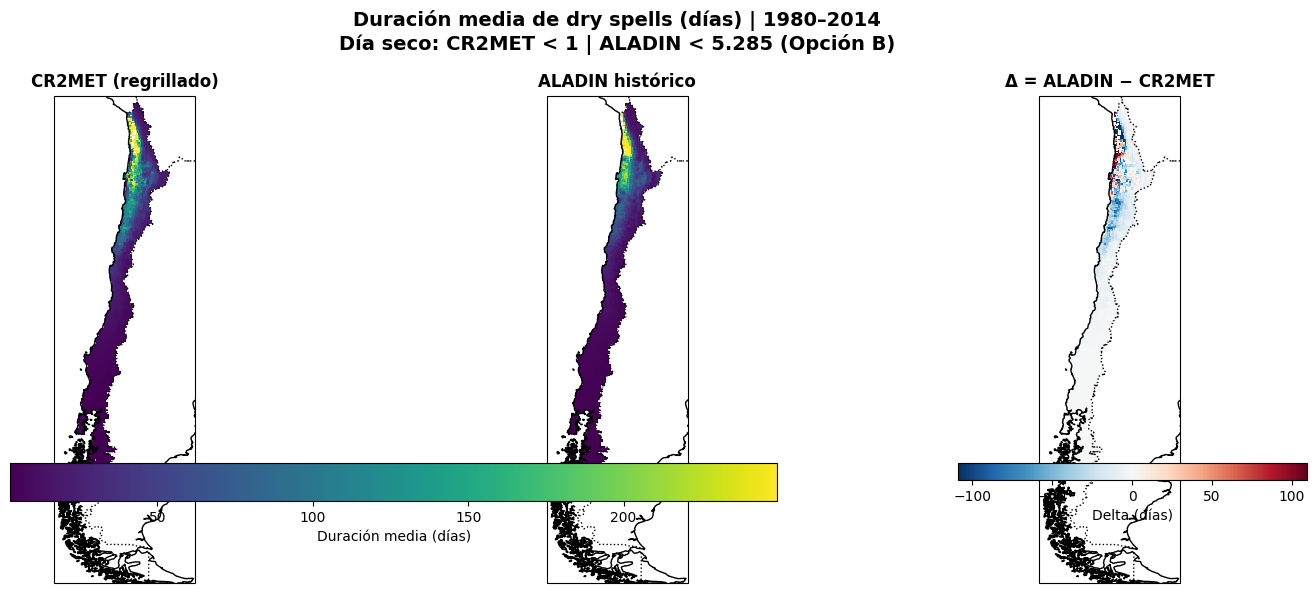

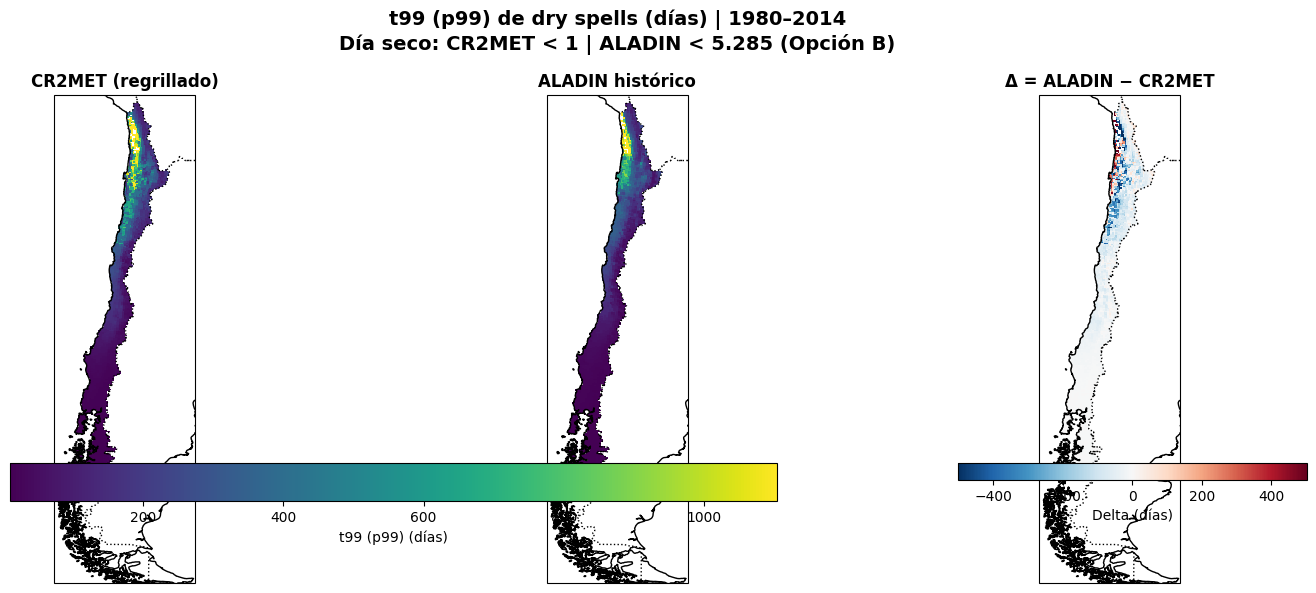

4/4: Resumen numérico (promedios espaciales)...


,dataset,metrica,mean_espacial,median_espacial,min,max
0,CR2MET,Duración media,42.456,17.062,2.371,424.900
1,ALADIN,Duración media,35.065,12.308,2.455,425.067
2,DELTA (ALADIN-CR2MET),Duración media,-7.868,-2.181,-337.181,342.850
3,CR2MET,t99 (p99),221.770,133.000,9.000,2561.700
4,ALADIN,t99 (p99),178.183,93.890,9.000,2422.020
5,DELTA (ALADIN-CR2MET),t99 (p99),-44.737,-16.860,-1451.340,2081.020


Nota: si COMPUTE_TL=False, no se calcula tL (más inestable y costosa).


In [6]:
# =====================================================================
# MAPAS: CR2MET / ALADIN / DELTA
# =====================================================================
def plot_three_panel_maps(cr2_da, ala_da, delta_da, *, title, cbar_label, cmap_main='viridis', cmap_delta='RdBu_r', vmin=None, vmax=None, dv=None):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': ccrs.PlateCarree()})
    for ax in axes:
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        ax.set_extent(CHILE_EXTENT)

    im0 = cr2_da.plot.pcolormesh(
        ax=axes[0], x='lon', y='lat', transform=ccrs.PlateCarree(), cmap=cmap_main,
        vmin=vmin, vmax=vmax, add_colorbar=False,
    )
    axes[0].set_title('CR2MET (regrillado)', fontweight='bold')

    im1 = ala_da.plot.pcolormesh(
        ax=axes[1], x='lon', y='lat', transform=ccrs.PlateCarree(), cmap=cmap_main,
        vmin=vmin, vmax=vmax, add_colorbar=False,
    )
    axes[1].set_title('ALADIN histórico', fontweight='bold')

    if dv is None:
        vals = delta_da.where(chile_mask).values.ravel()
        vals = vals[np.isfinite(vals)]
        dv = float(np.nanpercentile(np.abs(vals), 98)) if vals.size else 1.0
        dv = max(dv, 0.5)

    im2 = delta_da.plot.pcolormesh(
        ax=axes[2], x='lon', y='lat', transform=ccrs.PlateCarree(), cmap=cmap_delta,
        vmin=-dv, vmax=dv, add_colorbar=False,
    )
    axes[2].set_title('Δ = ALADIN − CR2MET', fontweight='bold')

    cbar0 = fig.colorbar(im1, ax=axes[:2].ravel().tolist(), orientation='horizontal', shrink=0.85, pad=0.08)
    cbar0.set_label(cbar_label)
    cbar1 = fig.colorbar(im2, ax=[axes[2]], orientation='horizontal', shrink=0.85, pad=0.08)
    cbar1.set_label('Delta (días)')

    plt.suptitle(title, fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()


def summarize_map(da, label):
    vals = da.where(chile_mask).values.ravel()
    vals = vals[np.isfinite(vals)]
    return {
        'metrica': label,
        'mean_espacial': float(np.nanmean(vals)) if vals.size else np.nan,
        'median_espacial': float(np.nanmedian(vals)) if vals.size else np.nan,
        'min': float(np.nanmin(vals)) if vals.size else np.nan,
        'max': float(np.nanmax(vals)) if vals.size else np.nan,
    }


print('3/4: Generando mapas...')

for key, label in [('mean', 'Duración media'), ('t99', 't99 (p99)'), ('tL', 'tL (cutoff)')]:
    if key == 'tL' and not COMPUTE_TL:
        continue

    cr2 = metrics_cr2[key]
    ala = metrics_ala[key]
    dlt = metrics_delta[key]

    # Escala común para CR2MET y ALADIN
    vals = np.concatenate([
        cr2.where(chile_mask).values.ravel(),
        ala.where(chile_mask).values.ravel(),
    ])
    vals = vals[np.isfinite(vals)]
    if vals.size:
        vmin = float(np.nanpercentile(vals, 2))
        vmax = float(np.nanpercentile(vals, 98))
    else:
        vmin, vmax = None, None

    plot_three_panel_maps(
        cr2, ala, dlt,
        title=(
            f'{label} de dry spells (días) | {START_DATE[:4]}–{END_DATE[:4]}\n'
            f'Día seco: CR2MET < {DRY_THRESHOLD_CR2MET:g} | ALADIN < {DRY_THRESHOLD_ALADIN:g} (Opción B)'
        ),
        cbar_label=f'{label} (días)',
        vmin=vmin, vmax=vmax,
    )

print('4/4: Resumen numérico (promedios espaciales)...')
rows = []
for key, label in [('mean', 'Duración media'), ('t99', 't99 (p99)'), ('tL', 'tL (cutoff)')]:
    if key == 'tL' and not COMPUTE_TL:
        continue
    rows.append({'dataset': 'CR2MET', **summarize_map(metrics_cr2[key], label)})
    rows.append({'dataset': 'ALADIN', **summarize_map(metrics_ala[key], label)})
    rows.append({'dataset': 'DELTA (ALADIN-CR2MET)', **summarize_map(metrics_delta[key], label)})

summary_df = pd.DataFrame(rows)
display(summary_df.round(3))

print('Nota: si COMPUTE_TL=False, no se calcula tL (más inestable y costosa).')
